<a href="https://drive.google.com/file/d/1PHsseBcbfwHPGOOPlpuM1JRSguVYRSr2/view?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Monte Carlo con Políticas epsilon-soft**

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium` para la simulación, con el objetivo de crear un ambiente controlado para que el agente pueda interactuar.
- **Importación de Librerías**: Se importan las bibliotecas necesarias como `numpy` para el manejo de matrices y `matplotlib` para la visualización de los resultados.

- **Importación del Entorno "FrozenLake"**:
Se cargan dos versiones del entorno "FrozenLake": una de 4x4 y otra de 8x8. Ambas versiones no son resbaladizas, lo que facilita la comprensión de los resultados, dado que el entorno resbaladizo podría dificultar la comprensión inicial del aprendizaje.

#### 3. **Funciones para Mostrar los Resultados**
   - Se define una función para graficar la proporción de recompensas obtenidas en cada episodio del entrenamiento. Esto ayuda a visualizar el progreso del agente en términos de su desempeño durante el entrenamiento.



##### _________ **Código de la Instalación e Importación**
----

In [ ]:
%%capture
#@title Instalamos gymS
!pip install 'gym[box2d]==0.20.0'

In [ ]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import random


Establecemos una semilla para mantener una reproducibilidad

In [ ]:
# Establecer la semilla global para reproducibilidad
global_seed = 100
np.random.seed(global_seed)
random.seed(global_seed)

In [ ]:
#@title Importamos el lago helado
name = 'FrozenLake-v1'
env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode="ansi") # No resbaladizo para entender mejor los resultados.
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode="ansi") # No resbaladizo para entender mejor los resultados.

## **2. Diseño del Agente**

El diseño del agente consta de dos partes, el algoritmo con el que aprende y las políticas (toma de decisiones) que realiza.

- **Políticas del Agente**
   - **Política epsilon-soft**: Se define una política donde todas las acciones tienen una probabilidad de ser elegida.
   - **Política epsilon-greedy**: basada en la política epsilon-soft. De esta forma el agente tiene una pequeña probabilidad de explorar (tomar una acción aleatoria) y una mayor probabilidad de explotar (tomar la acción que considera mejor). Esto permite equilibrar la exploración y la explotación.
   - **Política greedy**: Es la usada una vez que "ha aprendido".

- **Algoritmo de Iteración de Valor**
  - Se implementa el algoritmo de iteración de valor utilizando Monte Carlo.
  - Se usa una versión "on-policy" de Monte Carlo con políticas epsilon greedy sobre una política epsilon-soft.
  - Se basa en el criterio de todas las visitas.
  - Otro aspecto es que la actualización de los retornos no se realiza en el orden inverso a las visitas.

#### **Código de las políticas y algoritmo MC**
----------------

In [ ]:
# @title Políticas del agente

# actions
LEFT, DOWN, RIGHT, UP = 0,1,2,3

# Política epsilon-soft. Se usa para el entrenamiento
def random_epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = np.ones(nA, dtype=float) * epsilon / nA
    best_action = np.argmax(Q[state])
    pi_A[best_action] += (1.0 - epsilon)
    return pi_A

# Política epsilon-greedy a partir de una epsilon-soft
def epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = random_epsilon_greedy_policy(Q, epsilon, state, nA)
    return np.random.choice(np.arange(nA), p=pi_A)

# Política Greedy a partir de los valones Q. Se usa para mostrar la solución.
def pi_star_from_Q(env, Q):
    done = False
    pi_star = np.zeros([env.observation_space.n, env.action_space.n])
    state, info = env.reset() # start in top-left, = 0
    actions = ""
    while not done:
        action = np.argmax(Q[state, :])
        actions += f"{action}, "
        pi_star[state,action] = action
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
    return pi_star, actions

## 2.1. Definimos el agente para frozen lake con montecarlo

Se realiza la integración del método montecarlo propuesto dentro del agente, lo que conlleva cambiar la función a una clase que será el agente. Se conserva, no obstante, los bucles de entrenamiento, y se añaden en el bucle las operaciones necesarias para almacenar el número de pasos por episodio.

Se han realizado varios cambios sobre el MonteCarlo propuesto para que sera un MonteCarlo puro:

>Almacenamiento de recompensas:
Se modificó la estructura de los episodios para almacenar tuplas (state,action,reward) en lugar de solo (state,action). Esto permite calcular el retorno G a partir de cada paso.

>Eliminación de la variable acumulativa global:
Se eliminó la variable result_sum (que acumulaba todas las recompensas del episodio) y se reemplazó por el cálculo de G en cada paso.

>Cálculo del retorno G por paso:
Al finalizar el episodio se recorre la lista de tuplas en orden inverso, calculando para cada paso el retorno G=r+γ×G. Este valor es el retorno acumulado desde ese instante en adelante.

>Actualización de la función Q:
Cada par (s,a) se actualiza utilizando su correspondiente retorno G (en lugar del retorno total del episodio) para lograr el enfoque de Monte Carlo puro.

>Actualización de estadísticas:
Se modificó el modo de actualizar las estadísticas acumuladas, utilizando el G calculado para el primer paso del episodio.

Estos cambios permiten que el agente actualice sus estimaciones Q(s,a) de forma coherente con el retorno real acumulado a partir de cada visita, siguiendo la metodología de Monte Carlo puro.

Adicionalmente se ha añadido un truncamiento de episodios, en el caso de que en alguna iteración el número de pasos supere al del obtenido en la mejor iteración que haya sido exitosa (reward 1), dado que no tiene sentido explorar caminos más largos que aquellos que son exitosos y son más cortos. De esta forma se optimiza el rendimiento del entrenamiento enfocado en un objetivo de búsqueda de mínimos globales.

In [ ]:
class MCAgent:
    def __init__(self, env, epsilon=0.4, discount_factor=1.0, seed=123):
        self.env = env
        self.epsilon = epsilon
        self.discount_factor = discount_factor
        self.nA = env.action_space.n
        self.n_states = env.observation_space.n
        self.Q = np.zeros((self.n_states, self.nA))
        self.n_visits = np.zeros((self.n_states, self.nA))
        self.best_steps = None  # Almacena el número de pasos del mejor camino exitoso
        self.seed = seed

        # Establecer semilla para reproducibilidad en numpy y random
        np.random.seed(self.seed)
        random.seed(self.seed)

    def choose_action(self, state):
        return epsilon_greedy_policy(self.Q, self.epsilon, state, self.nA)

    def train(self, num_episodes=5000, decay=False, epsilon0=1.0, epsilon_min=0.05, lambd=0.001):
        episode_lengths = []  # Para guardar la longitud de cada episodio
        list_stats = []       # Para almacenar la evolución de la recompensa promedio
        total_return = 0.0
        step_display = max(1, num_episodes // 10)

        for t in tqdm(range(num_episodes)):
            # Actualizar epsilon con decaimiento exponencial
            if decay:
                self.epsilon = epsilon_min + (epsilon0 - epsilon_min) * np.exp(-lambd * t)

            # Reiniciar el entorno con una semilla única para este episodio
            state, info = self.env.reset(seed=self.seed + t)
            done = False
            episode = []         # Lista de tuplas (estado, acción, recompensa)
            step_count = 0       # Contador de pasos en el episodio

            # Generar el episodio
            while not done:
                action = self.choose_action(state)
                new_state, reward, terminated, truncated, info = self.env.step(action)
                episode.append((state, action, reward))
                state = new_state
                step_count += 1
                done = terminated or truncated

                # Corte anticipado si se supera el número de pasos del mejor camino conocido
                if self.best_steps is not None and step_count >= self.best_steps:
                    done = True

            episode_lengths.append(step_count)

            # Calcular el retorno G de cada paso de forma retroactiva
            returns = []  # Cada elemento será (estado, acción, G)
            G = 0
            for s, a, r in reversed(episode):
                G = r + self.discount_factor * G
                returns.append((s, a, G))
            returns.reverse()  # Ahora returns[0] corresponde al primer paso del episodio

            # Actualizar la función Q para cada par (estado, acción)
            for s, a, G in returns:
                self.n_visits[s, a] += 1.0
                alpha = 1.0 / self.n_visits[s, a]
                self.Q[s, a] += alpha * (G - self.Q[s, a])

            # Actualizar estadísticas utilizando el retorno del primer paso del episodio
            total_return += returns[0][2]
            list_stats.append(total_return / (t + 1))

            # Actualizar el mejor camino si el episodio fue exitoso (reward 1 en el último paso)
            if episode[-1][2] == 1:
                if self.best_steps is None or step_count < self.best_steps:
                    self.best_steps = step_count

            if t % step_display == 0 and t != 0:
                print(f"Episode {t}, Average return: {total_return/t}, Epsilon: {self.epsilon}, Best Steps: {self.best_steps}")

        return self.Q, list_stats, episode_lengths


## **3. Experimentación**

   - En esta sección, el algoritmo de Monte Carlo con la política epsilon-soft se ejecuta tanto para el entorno de 4x4 como al de 8x8 de FrozenLake sin resbalar.
   
   - En ambos casos se realiza un entrenamiento con un número determinado de episodios (5000 en concreto)

   - Además en el escenario 8x8 el  epsilon tiene decaimiento de acuerdo a la expresión: $\epsilon = min(1.0, 1000.0/(t+1))$

   - Durante el entrenamiento hay una visualización de la proporción de recompensas obtenidas a lo largo del entrenamiento.

   - Junto a dicho volcado se muestra gráficamente la proporcion de recompensas obtendias.

   

### **3.1 Repressentaciones Gráficas**

Para comprobar el aprendizaje se mostrará la función $f(t)=\frac{\sum_{i=1}^t R_i}{t}$ para $t=1,2,\ldots, NumeroEpisodios$. La justificación es la siguiente. Como sabemmos que el retorno en el estados inicial 1 (pues no hay descuento) o 9, si se divide por el número de episodios ejecutados se calcular el porcentaje de recompensas positivas obtenidas. Dicho de otra forma, nos dirá el porcentaje de veces que el agente ha llegado al estado terminal.


In [ ]:
# @title Funciones para mostrar los resultados

def plot(list_stats):
  # Creamos una lista de índices para el eje x
  indices = list(range(len(list_stats)))

  # Creamos el gráfico
  plt.figure(figsize=(6, 3))
  plt.plot(indices, list_stats)

  # Añadimos título y etiquetas
  plt.title('Proporción de recompensas')
  plt.xlabel('Episodio')
  plt.ylabel('Proporción')

  # Mostramos el gráfico
  plt.grid(True)
  plt.show()


### **3.2 Experimentación en el escenario 4x4**



   - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ constante




In [ ]:
agent = MCAgent(env4, epsilon=1, discount_factor=1)

# Entrena al agente usando su método train
Q, list_stats, episode_lengths = agent.train(num_episodes=50000, lambd=0.001, decay=True)

 11%|█         | 5261/50000 [00:02<00:22, 1991.81it/s]

Episode 5000, Average return: 0.4964, Epsilon: 0.056401049649131195, Best Steps: 6


 21%|██        | 10382/50000 [00:05<00:19, 2082.76it/s]

Episode 10000, Average return: 0.6526, Epsilon: 0.050043129933274366, Best Steps: 6


 30%|███       | 15227/50000 [00:07<00:17, 1992.58it/s]

...

 80%|████████  | 40240/50000 [00:21<00:06, 1591.35it/s]

Episode 40000, Average return: 0.77485, Epsilon: 0.05000000000000001, Best Steps: 6


 91%|█████████ | 45286/50000 [00:24<00:02, 1944.59it/s]

Episode 45000, Average return: 0.7798222222222222, Epsilon: 0.05, Best Steps: 6


100%|██████████| 50000/50000 [00:26<00:00, 1880.50it/s]


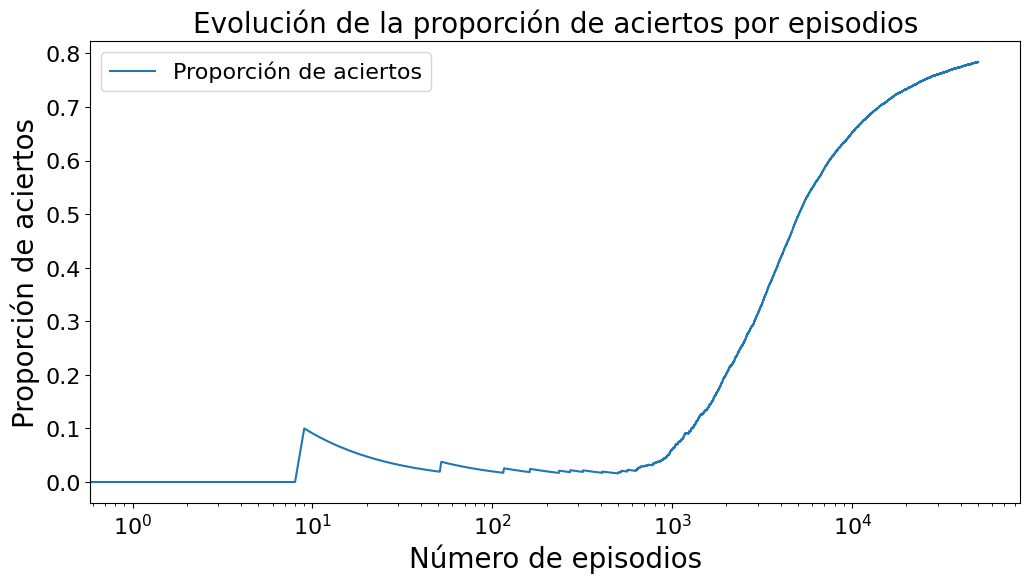

Máxima proporción: 0.78398


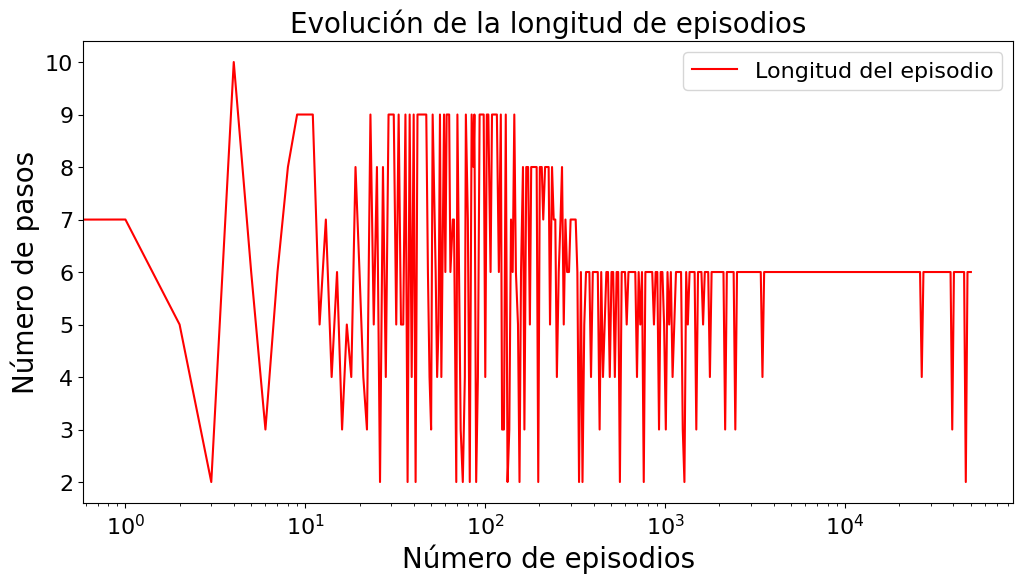

In [ ]:
#@title Proporción de aciertos por número de episodios
plt.figure(figsize=(12, 6))
plt.plot(list_stats, label="Proporción de aciertos")
plt.xlabel('Número de episodios', fontsize=20)
plt.ylabel('Proporción de aciertos', fontsize=20)
plt.xscale('log')
plt.title('Evolución de la proporción de aciertos por episodios', fontsize=20)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

print(f"Máxima proporción: {list_stats[-1]}")

# Graficar la longitud de cada episodio con muestreo logarítmico
log_indices = np.unique(np.logspace(0, np.log10(len(episode_lengths)), num=500, dtype=int) - 1)
sampled_episode_lengths = [episode_lengths[i] for i in log_indices]

plt.figure(figsize=(12, 6))
plt.plot(log_indices, sampled_episode_lengths, label="Longitud del episodio", color='red', alpha=1)
plt.xlabel('Número de episodios', fontsize=20)
plt.xscale('log')
plt.ylabel('Número de pasos', fontsize=20)
plt.title('Evolución de la longitud de episodios', fontsize=20)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()


Como vemos el número de episodios desciende rápidamente en el momento en el que encuentra  un camino exitoso, y todos los intentos de exploración posteriores se truncan a el número de pasos del mejor camino encontrado hasta el momento. Por esa razón se puede observar la apariencia de escalera a medida que avanza el entrenamiento.

### **3.3 Experimentación en el escenario 8x8**

  - Se realizan 5000 epsisodios y se actualizan los valores Q (valor de acción) basándose en las recompensas obtenidas durante cada episodio completo (e.d. aplicamos Monte Carlo) Se apica una política $\epsilon$ greedy sobre una política $\epsilon$ soft con un valor $\epsilon$ decreciente



In [ ]:
# @title Aprendizaje
agent = MCAgent(env8, epsilon=1, discount_factor=1)

# Entrena al agente usando su método train
Q, list_stats, episode_lengths = agent.train(num_episodes=50000, lambd=0.0002, decay=True)

 10%|█         | 5159/50000 [00:06<00:45, 987.91it/s] 

Episode 5000, Average return: 0.0032, Epsilon: 0.3994854691128702, Best Steps: 14


 20%|██        | 10149/50000 [00:11<00:40, 991.51it/s]

Episode 10000, Average return: 0.0431, Epsilon: 0.17856851907478205, Best Steps: 14


 30%|███       | 15138/50000 [00:17<00:37, 918.35it/s]

...

 80%|████████  | 40124/50000 [00:44<00:11, 888.66it/s] 

Episode 40000, Average return: 0.412975, Epsilon: 0.05031868949650739, Best Steps: 14


 90%|█████████ | 45122/50000 [00:50<00:04, 1023.39it/s]

Episode 45000, Average return: 0.43733333333333335, Epsilon: 0.05011723931388235, Best Steps: 14


100%|██████████| 50000/50000 [00:55<00:00, 899.48it/s] 


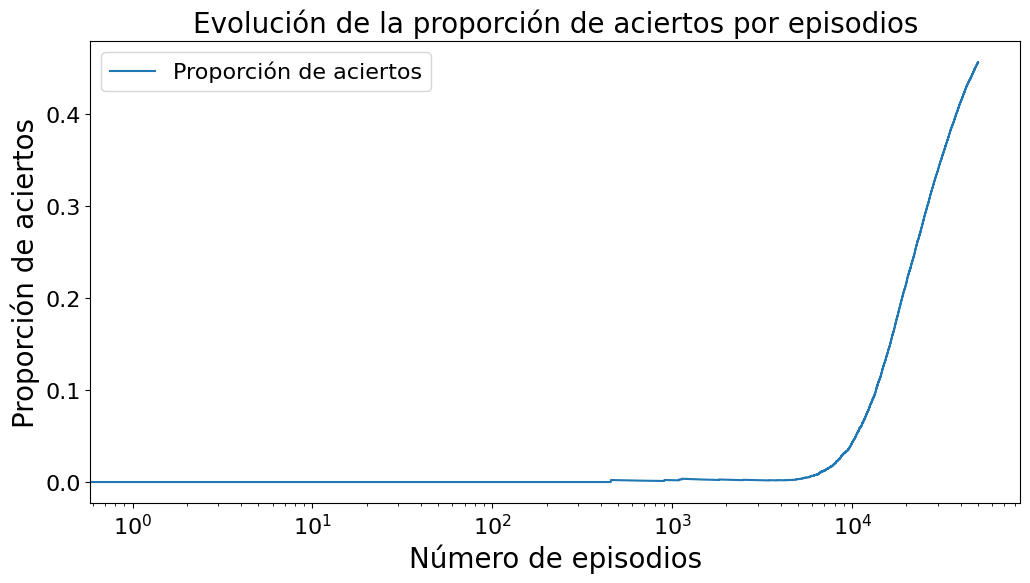

Máxima proporción: 0.4565


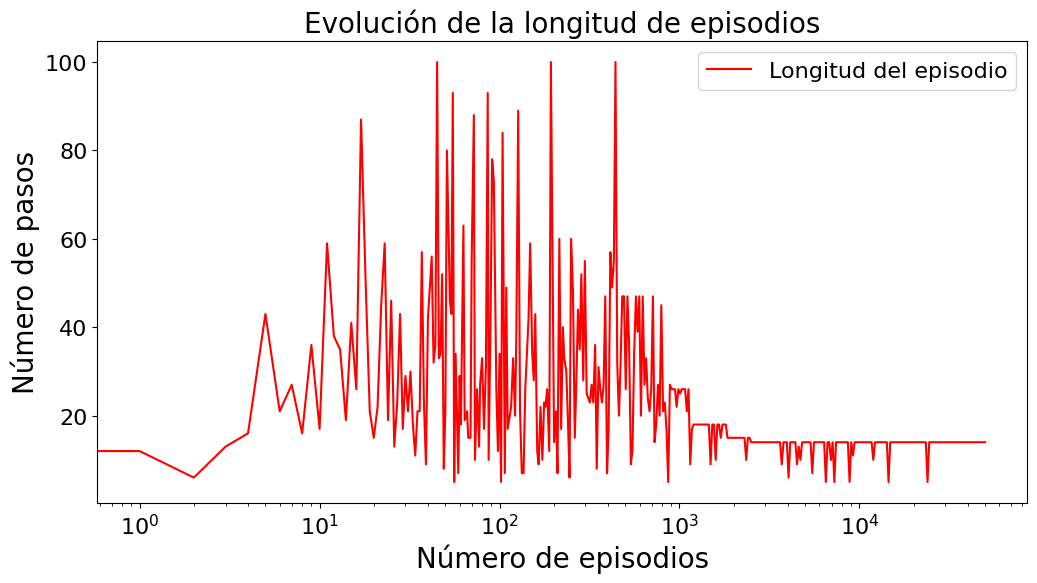

In [ ]:
#@title Proporción de aciertos por número de episodios
plt.figure(figsize=(12, 6))
plt.plot(list_stats, label="Proporción de aciertos")
plt.xlabel('Número de episodios', fontsize=20)
plt.ylabel('Proporción de aciertos', fontsize=20)
plt.xscale('log')
plt.title('Evolución de la proporción de aciertos por episodios', fontsize=20)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

print(f"Máxima proporción: {list_stats[-1]}")

# Graficar la longitud de cada episodio con muestreo logarítmico
log_indices = np.unique(np.logspace(0, np.log10(len(episode_lengths)), num=500, dtype=int) - 1)
sampled_episode_lengths = [episode_lengths[i] for i in log_indices]

plt.figure(figsize=(12, 6))
plt.plot(log_indices, sampled_episode_lengths, label="Longitud del episodio", color='red', alpha=1)
plt.xlabel('Número de episodios', fontsize=20)
plt.xscale('log')
plt.ylabel('Número de pasos', fontsize=20)
plt.title('Evolución de la longitud de episodios', fontsize=20)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()


Similar al caso del mapa 4x4, vemos como en el 8x8 el algoritmo encuentra mínimos locales, lo que va limitando la longitud máxima de los siguientes episodios, y conforme sigue explorando va acercándose al mínimo global.

En este caso, a diferencia del anterior, la mayor complejidad del mapa requiere de un mayor número de iteraciones para lograr obtener recompensas, alrededor de 1000 vs 15 en el caso del 4x4.

De nuevo, una vez que epsilon se reduce lo suficiente, la tasa de éxito converge a 1, dado que se dedica un mayor número de episodios a explotación y menos a exploración.

####.
Mostramos los valores Q para cada estado. Cada estado tienen 4 valores, que se corresponden con las 4 acciones que se pueden en cada estado.

## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**

- Se observa que en ambos entornos el agente es capaz de aprender y mejorar su tasa de éxito a medida que avanzan los episodios.

- La característica implementada del corte anticipado permite una mejor visualización de resultados y un mejor tiempo de entrenamiento

- El algoritmo de MonteCarlo ha resultado exitoso en la resolución del problema.

### **4.2 Propuestas para Estudios Futuros**

- Sería interesante comparar el desempeño de otros algoritmos distintos a montecarlo para resolver el problema del Frozen Lake, con el objetivo de comparar tiempos de entrenamiento, tasa de éxito etc.

- También se podrían incluir otras políticas distintas para evaluar su desempeño con distintos algoritmos.
